To leave enough time for the molecular dynamics (MD) part of the workshop, we will only briefly look into these tasks now.

### Tasks

Choose any or all of the following tasks to try and use MACE with ASE.

1. Repeat the FCC cell optimization we originally did with GPAW.
2. Use the monoclinic cell instead.
3. Remove any one atom from the starting structure<br>
   (a) optimize using MACE<br>
   (b) make the cell larger before removing an atom and repeat<br>
   Do you see differences? Is the repeated defect in the original defects receptive field?<br>
4. Visualize the trajectories and optimized structures
5. Calculate the equation of states using an FMLIP
6. Try another structure from The Materials Project
7. Try different optimizers
8. Try different FMLIPs
9. From any MACE relaxation<br>
   (a) evaluate the optimized result with GPAW (single shot)<br>
   (b) compare the force predictions (plot, RMSE)<br>
   (c) you can compare different MLIPs in the same way

In [1]:


import pathlib

import ase.io
import numpy as np

from ase.eos import EquationOfState
from ase.optimize import LBFGS
from tqdm.auto import tqdm


def calculate_eos(atoms, calc, grid=np.linspace(0.95, 1.05, 7)):
    """ Calculate the eos for given atoms and calculator.
    """
    volumes = []
    energies = []
    
    original_cell = atoms.get_cell()
    
    for g in tqdm(grid):
        atoms.set_cell(original_cell * g, scale_atoms=True)
        volumes.append(atoms.get_volume())
        
        # relax the atom positions
        btoms = atoms.copy()
        btoms.calc = calc
        opt = LBFGS(
            btoms,
            trajectory=None,
            logfile=None,
        )
        converged = opt.run(fmax=0.001)
        if converged:
            energies.append(btoms.get_potential_energy())
        else:
            raise Exception("Failed to converge atom positions.")

    eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
    
    v0, e0, B = eos.fit()
    print(f"Equilibrium volume: {v0:.3f} A^3")
    print(f"Bulk Modulus: {B * 160.217:.3f} GPa") # Convert eV/A^3 to GPa

    return eos

/Users/rwanzenboeck/Documents/theochem/workshops/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/Users/rwanzenboeck/Documents/theochem/workshops/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Cached MACE model to /Users/rwanzenboeck/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /Users/rwanzenboeck/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


  0%|          | 0/7 [00:00<?, ?it/s]

Equilibrium volume: 42.989 A^3
Bulk Modulus: 101.870 GPa


<Axes: title={'center': 'birchmurnaghan: E: -12.477 eV, V: 42.989 Å$^3$, B: 101.870 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

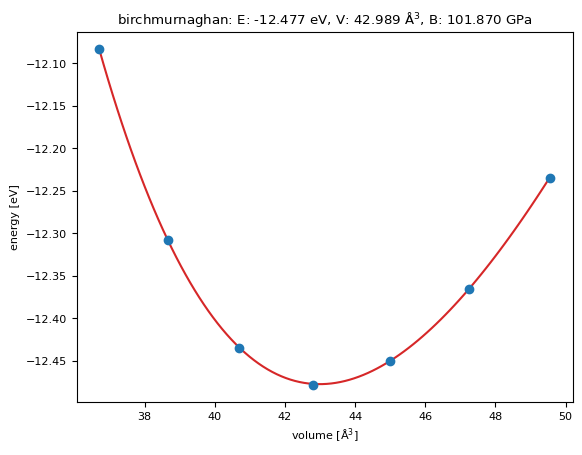

In [2]:
from mace.calculators import MACECalculator, mace_mp

calc = mace_mp(model="small")

atoms = ase.io.read(pathlib.Path.cwd().parents[1] / "data" / "Cu2S_FCC" / "Cu2S_prim.extxyz")
atoms.calc = calc

eos = calculate_eos(atoms=atoms, calc=calc)
eos.plot()

/Users/rwanzenboeck/Documents/theochem/workshops/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Cached MACE model to /Users/rwanzenboeck/.cache/mace/macemh1model
Using Materials Project MACE for MACECalculator with /Users/rwanzenboeck/.cache/mace/macemh1model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


  0%|          | 0/7 [00:00<?, ?it/s]

Equilibrium volume: 43.568 A^3
Bulk Modulus: 95.804 GPa


<Axes: title={'center': 'birchmurnaghan: E: -11.747 eV, V: 43.568 Å$^3$, B: 95.804 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

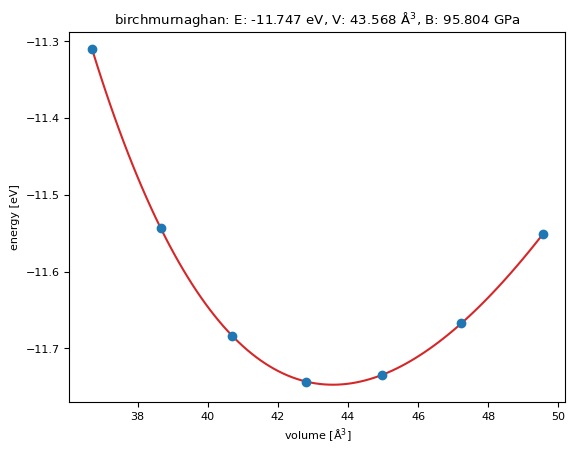

In [4]:
from mace.calculators import MACECalculator, mace_mp

calc = mace_mp(model="mh-1", head="omat_pbe")

atoms = ase.io.read(pathlib.Path.cwd().parents[1] / "data" / "Cu2S_FCC" / "Cu2S_prim.extxyz")
atoms.calc = calc

eos = calculate_eos(atoms=atoms, calc=calc)
eos.plot()